In [55]:
import cv2
import pickle
from natsort import natsorted
import numpy as np
from matplotlib import pyplot as plt

In [56]:
data_fname = 'data.pickle'

In [57]:
with open(data_fname, 'rb') as handle:
    data = pickle.load(handle)

In [58]:
natsorted(data.keys())

['0.pickle',
 '1.pickle',
 '2.pickle',
 '3.pickle',
 '4.pickle',
 '5.pickle',
 '6.pickle',
 '7.pickle',
 '8.pickle',
 '9.pickle',
 '10.pickle',
 '11.pickle',
 '12.pickle',
 '13.pickle',
 '14.pickle',
 '15.pickle',
 '16.pickle',
 '17.pickle',
 '18.pickle',
 '19.pickle',
 '20.pickle',
 '21.pickle',
 '22.pickle',
 '23.pickle',
 '24.pickle',
 '25.pickle',
 '26.pickle',
 '27.pickle',
 '28.pickle',
 '29.pickle',
 '30.pickle',
 '31.pickle',
 '32.pickle',
 '33.pickle',
 '34.pickle',
 '35.pickle',
 '36.pickle',
 '37.pickle']

# Визуализация

In [59]:
id = 2

fname = f'{id}.pickle'

img_size = data[fname]['img_size']
bboxes = data[fname]['bboxes']

In [60]:
img = np.zeros(img_size, dtype=np.uint8)
img.fill(255)

for x1, y1, x2, y2 in bboxes:
    img = cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 0), 2)

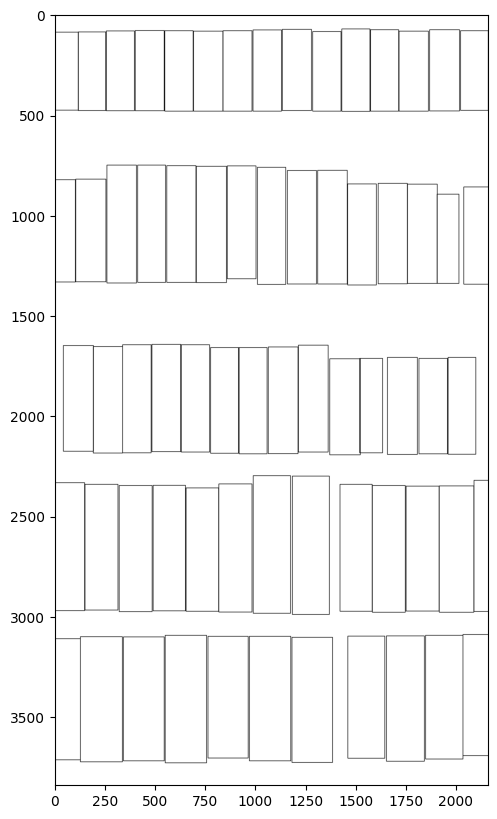

In [61]:
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.show()

# Задание

Написать функцию divide_by_shelfs, принимающую на вход bboxes, img_size и возвращающую для каждого прямоугольника из bboxes номер полки. Нумерация сверху-вниз с нуля.

## Подход к решению

Товары на одной полке имеют близкие вертикальные координаты центров (y-центры), а между полками-  заметные разрывы. Задача сводится к 1D-кластеризации y-центров bbox-ов.

Алгоритм состоит из трёх шагов:
1. Начальная сегментация: найти порог, разделяющий внутриполочные (малые) зазоры от межполочных (больших относительно первых).
2. Слияние артефактов: мелкие группы (< 3 элементов) объединяются с ближайшей полкой.
3. Дробление крупных групп: если полка содержит аномально много элементов и внутри неё есть явный разрыв, она разбивается дополнительно.

### `_otsu_threshold` — порог по методу Оцу

[Метод Оцу](https://ru.wikipedia.org/wiki/Метод_Оцу) перебирает все возможные пороги и выбирает тот, который максимизирует межклассовую дисперсию: то есть лучше всего разделяет малые (внутриполочные) зазоры от больших (межполочных).

In [62]:
def _otsu_threshold(values):
    sv = sorted(values)
    n = len(sv)
    if n < 2:
        return float('inf')
    best_t, best_var = sv[-1], -1
    for i in range(1, n):
        w1, w2 = i / n, (n - i) / n
        m1 = sum(sv[:i]) / i
        m2 = sum(sv[i:]) / (n - i)
        var = w1 * w2 * (m1 - m2) ** 2
        if var > best_var:
            best_var = var
            best_t = (sv[i - 1] + sv[i]) / 2
    return best_t

### `_natural_break` - порог по наибольшему разрыву

Сортирую значения и ищю наибольший скачок между соседними элементами. Порог ставится в середине этого скачка. Используется на этапе дробления крупных групп, когда внутри одной «полки» может скрываться граница между двумя реальными полками.

In [63]:
def _natural_break(values):
    sv = sorted(values)
    if len(sv) < 2:
        return float('inf')
    max_gap, idx = 0, 0
    for j in range(len(sv) - 1):
        gap = sv[j + 1] - sv[j]
        if gap > max_gap:
            max_gap, idx = gap, j
    return (sv[idx] + sv[idx + 1]) / 2

### `divide_by_shelfs`

1. Вычисляю y-центры всех bbox-ов и сортирую их.
2. Считаю зазоры между соседними отсортированными y-центрами.
3. При помощи метода Оцу на зазорах делаю начальное разбиение на полки.
4. Слияние мелких групп с ближайшей по среднему y-центру полкой: убирает артефакты (одиночные bbox-ы, ошибочно выделенные в отдельную полку).
5. Дробление крупных групп: если размер полки больше в 1.5 раза медианы и внутри есть разрыв (max_gap / median_gap > 2.5), разбиваю через Natural Break.

In [64]:

def divide_by_shelfs(bboxes, img_size):
    n = len(bboxes)
    y_centers = [(y1 + y2) / 2 for x1, y1, x2, y2 in bboxes]

    if n <= 1:
        return [0] * n

    order = sorted(range(n), key=lambda k: y_centers[k])
    sorted_yc = [y_centers[k] for k in order]
    diffs = [sorted_yc[j + 1] - sorted_yc[j] for j in range(len(sorted_yc) - 1)]

    threshold = _otsu_threshold(diffs)

    shelves = []
    start = 0
    for j in range(len(diffs)):
        if diffs[j] > threshold:
            shelves.append((start, j + 1))
            start = j + 1
    shelves.append((start, n))

    changed = True
    while changed:
        changed = False
        for i in range(len(shelves)):
            s, e = shelves[i]
            if e - s < 3 and len(shelves) > 1:
                my_mean = sum(sorted_yc[k] for k in range(s, e)) / (e - s)
                best_j, best_dist = -1, float('inf')
                for j in range(len(shelves)):
                    if j == i:
                        continue
                    sj, ej = shelves[j]
                    other_mean = sum(sorted_yc[k] for k in range(sj, ej)) / (ej - sj)
                    if abs(my_mean - other_mean) < best_dist:
                        best_dist = abs(my_mean - other_mean)
                        best_j = j
                sj, ej = shelves[best_j]
                merged = (min(s, sj), max(e, ej))
                shelves = [sh for k, sh in enumerate(shelves) if k != i and k != best_j]
                shelves.append(merged)
                shelves.sort()
                changed = True
                break

    for _ in range(3):
        sizes = [e - s for s, e in shelves]
        if len(sizes) < 2:
            break
        median_size = sorted(sizes)[len(sizes) // 2]
        new_shelves, did_split = [], False

        for s, e in shelves:
            size = e - s
            if size > median_size * 1.5 and size >= 8:
                sub_yc = sorted_yc[s:e]
                sub_diffs = [sub_yc[j + 1] - sub_yc[j] for j in range(len(sub_yc) - 1)]
                sorted_sd = sorted(sub_diffs)
                med_d = sorted_sd[len(sorted_sd) // 2]
                max_d = sorted_sd[-1]

                if med_d > 0 and max_d / med_d > 2.5:
                    sub_thresh = _natural_break(sub_diffs)
                    parts, ps = [], 0
                    for j in range(len(sub_diffs)):
                        if sub_diffs[j] > sub_thresh:
                            parts.append((s + ps, s + j + 1))
                            ps = j + 1
                    parts.append((s + ps, e))

                    if all(pe - ps >= 3 for ps, pe in parts):
                        new_shelves.extend(parts)
                        did_split = True
                        continue

            new_shelves.append((s, e))

        shelves = new_shelves
        if not did_split:
            break

    labels = [0] * n
    for shelf_id, (s, e) in enumerate(shelves):
        for j in range(s, e):
            labels[order[j]] = shelf_id

    return labels

### Результаты на всех изображениях

In [65]:
for fname in natsorted(data.keys()):
    bboxes = data[fname]['bboxes']
    img_size = data[fname]['img_size']
    labels = divide_by_shelfs(bboxes, img_size)

    from collections import Counter
    counts = Counter(labels)
    n_shelves = max(labels) + 1
    shelf_items = [counts[s] for s in range(n_shelves)]
    print(f'{fname}: {n_shelves} shelves, items per shelf: {shelf_items}')

0.pickle: 5 shelves, items per shelf: [24, 22, 26, 21, 17]
1.pickle: 6 shelves, items per shelf: [17, 17, 16, 17, 15, 12]
2.pickle: 5 shelves, items per shelf: [15, 15, 14, 13, 11]
3.pickle: 5 shelves, items per shelf: [20, 18, 18, 15, 13]
4.pickle: 6 shelves, items per shelf: [13, 15, 15, 15, 13, 11]
5.pickle: 4 shelves, items per shelf: [50, 22, 23, 35]
6.pickle: 5 shelves, items per shelf: [17, 17, 16, 14, 11]
7.pickle: 6 shelves, items per shelf: [10, 10, 4, 14, 13, 11]
8.pickle: 5 shelves, items per shelf: [19, 19, 18, 15, 12]
9.pickle: 5 shelves, items per shelf: [37, 19, 19, 16, 13]
10.pickle: 5 shelves, items per shelf: [25, 19, 18, 15, 13]
11.pickle: 3 shelves, items per shelf: [10, 9, 7]
12.pickle: 5 shelves, items per shelf: [22, 19, 20, 18, 11]
13.pickle: 5 shelves, items per shelf: [9, 10, 10, 9, 5]
14.pickle: 5 shelves, items per shelf: [16, 16, 17, 14, 11]
15.pickle: 5 shelves, items per shelf: [11, 11, 12, 11, 10]
16.pickle: 6 shelves, items per shelf: [27, 26, 24, 24, 

### Визуализация (раскраска по полкам)

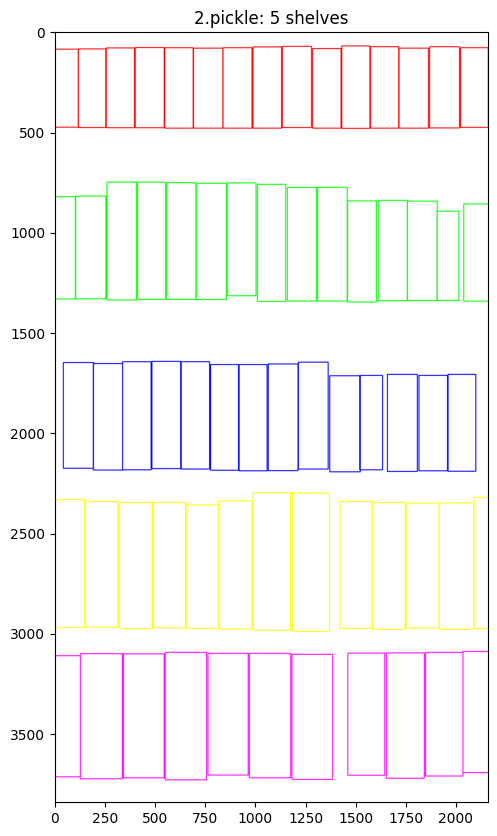

In [66]:
id = 2
fname = f'{id}.pickle'
img_size = data[fname]['img_size']
bboxes = data[fname]['bboxes']
labels = divide_by_shelfs(bboxes, img_size)

colors = [
    (255, 0, 0), (0, 255, 0), (0, 0, 255),
    (255, 255, 0), (255, 0, 255), (0, 255, 255),
    (128, 0, 0), (0, 128, 0), (0, 0, 128),
]

img = np.zeros(img_size, dtype=np.uint8)
img.fill(255)
for (x1, y1, x2, y2), label in zip(bboxes, labels):
    color = colors[label % len(colors)]
    img = cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)

plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.title(f'{fname}: {max(labels)+1} shelves')
plt.show()

## Метрики качества кластеризации

Так как в задаче нет разметки полок (как правильно разделить товары по полкам), использую внутренние метрики:

| Метрика | Что измеряет | Диапазон | Идеал |
|---------|-------------|----------|-------|
| Метод силуэтов | Насколько каждый объект ближе к своему кластеру, чем к чужому | [−1, 1] |  1 |
| Индекс Дэвиса-Болдина | Среднее пересечение между кластерами (отношение внутрикластерного разброса к межкластерному расстоянию) | [0, inf) |  0 |
| Inter / Intra ratio | Отношение среднего расстояния между центроидами полок к среднему внутриполочному разбросу | (0, inf) |  чем больше 1, тем лучше |

In [67]:
from collections import Counter


def compute_metrics(bboxes, labels):
    y_centers = np.array([(y1 + y2) / 2 for x1, y1, x2, y2 in bboxes])
    labels = np.array(labels)
    unique_labels = sorted(set(labels))
    n_clusters = len(unique_labels)

    if n_clusters < 2:
        return {"silhouette": float("nan"), "davies_bouldin": float("nan"), "inter_intra_ratio": float("nan")}

    centroids = []
    intra_spreads = []
    for k in unique_labels:
        members = y_centers[labels == k]
        centroids.append(members.mean())
        intra_spreads.append(members.std())
    centroids = np.array(centroids)
    intra_spreads = np.array(intra_spreads)

    sil_vals = []
    for i in range(len(y_centers)):
        own_label = labels[i]
        own_members = y_centers[labels == own_label]
        a_i = np.mean(np.abs(y_centers[i] - own_members)) if len(own_members) > 1 else 0.0

        b_i = float("inf")
        for k in unique_labels:
            if k == own_label:
                continue
            other_members = y_centers[labels == k]
            b_i = min(b_i, np.mean(np.abs(y_centers[i] - other_members)))

        sil_vals.append((b_i - a_i) / max(a_i, b_i, 1e-9))
    silhouette = float(np.mean(sil_vals))

    db_vals = []
    for i in range(n_clusters):
        max_ratio = 0.0
        for j in range(n_clusters):
            if i == j:
                continue
            ratio = (intra_spreads[i] + intra_spreads[j]) / max(abs(centroids[i] - centroids[j]), 1e-9)
            max_ratio = max(max_ratio, ratio)
        db_vals.append(max_ratio)
    davies_bouldin = float(np.mean(db_vals))

    inter_dists = []
    for i in range(n_clusters):
        for j in range(i + 1, n_clusters):
            inter_dists.append(abs(centroids[i] - centroids[j]))
    mean_inter = np.mean(inter_dists)
    mean_intra = np.mean(intra_spreads[intra_spreads > 0]) if np.any(intra_spreads > 0) else 1e-9
    inter_intra = float(mean_inter / mean_intra)

    return {"silhouette": silhouette, "davies_bouldin": davies_bouldin, "inter_intra_ratio": inter_intra}

all_sil, all_db, all_ratio = [], [], []

for fname in natsorted(data.keys()):
    bboxes = data[fname]["bboxes"]
    img_size = data[fname]["img_size"]
    labels = divide_by_shelfs(bboxes, img_size)
    m = compute_metrics(bboxes, labels)
    all_sil.append(m["silhouette"])
    all_db.append(m["davies_bouldin"])
    all_ratio.append(m["inter_intra_ratio"])

print(f"{'Метрика':<25} {'Среднее':>10} {'Мин':>10} {'Макс':>10}")
print("-" * 57)
print(f"{'Метод силуэтов':<25} {np.mean(all_sil):>10.3f} {np.min(all_sil):>10.3f} {np.max(all_sil):>10.3f}")
print(f"{'Индекс Дэвиса-Болдина':<25} {np.mean(all_db):>10.3f} {np.min(all_db):>10.3f} {np.max(all_db):>10.3f}")
print(f"{'Inter/Intra Ratio':<25} {np.mean(all_ratio):>10.1f} {np.min(all_ratio):>10.1f} {np.max(all_ratio):>10.1f}")

Метрика                      Среднее        Мин       Макс
---------------------------------------------------------
Метод силуэтов                 0.920      0.724      0.990
Индекс Дэвиса-Болдина          0.134      0.018      0.374
Inter/Intra Ratio               70.2        8.1      229.3


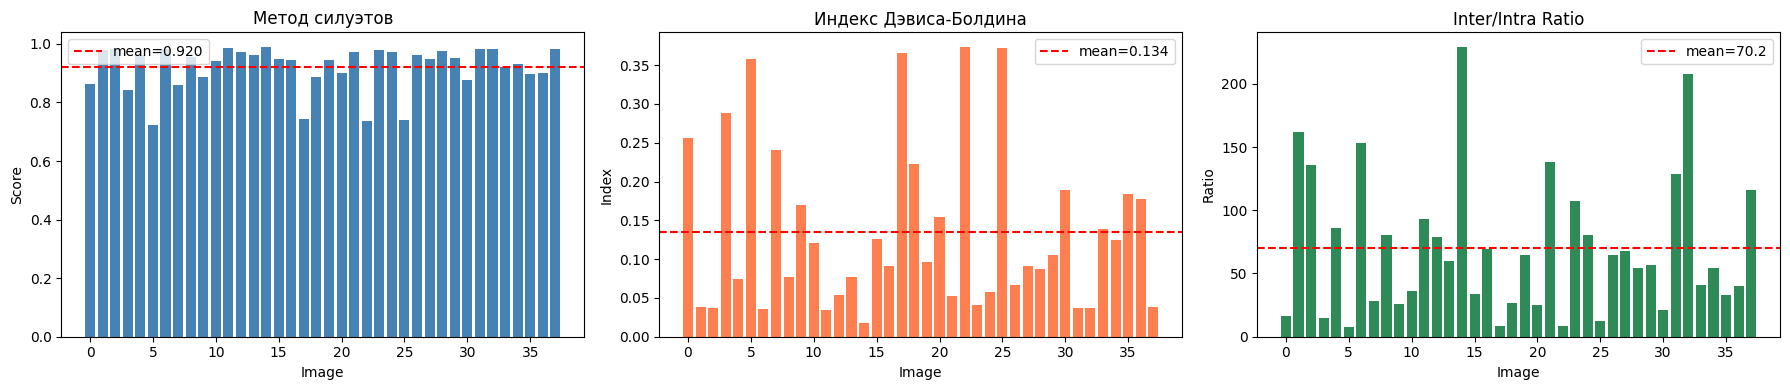

In [68]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

x = range(len(all_sil))
img_names = [f"{i}" for i in range(len(all_sil))]

axes[0].bar(x, all_sil, color="steelblue")
axes[0].axhline(np.mean(all_sil), color="red", linestyle="--", label=f"mean={np.mean(all_sil):.3f}")
axes[0].set_title("Метод силуэтов")
axes[0].set_xlabel("Image")
axes[0].set_ylabel("Score")
axes[0].legend()

axes[1].bar(x, all_db, color="coral")
axes[1].axhline(np.mean(all_db), color="red", linestyle="--", label=f"mean={np.mean(all_db):.3f}")
axes[1].set_title("Индекс Дэвиса-Болдина")
axes[1].set_xlabel("Image")
axes[1].set_ylabel("Index")
axes[1].legend()

axes[2].bar(x, all_ratio, color="seagreen")
axes[2].axhline(np.mean(all_ratio), color="red", linestyle="--", label=f"mean={np.mean(all_ratio):.1f}")
axes[2].set_title("Inter/Intra Ratio")
axes[2].set_xlabel("Image")
axes[2].set_ylabel("Ratio")
axes[2].legend()

plt.tight_layout()
plt.show()

## Выводы

Для разделения bbox-ов по полкам используется 1D-кластеризация y-центров в три этапа: порог Оцу для начального разбиения, слияние мелких артефактных групп и дробление аномально крупных кластеров через natural break.

### Качество.
- Метод силуэтов в среднем 0.92 на большинстве изображений, что говорит о хорошо разделённых кластерах. Минимальные значения (около 0.73) наблюдаются на изображениях с сильным перспективным искажением, где нижние полки сжаты.
- Индекс Дэвиса-Болдина близок к 0 (0.134): кластеры компактны и хорошо отделены друг от друга.
- Inter/Intra Ratio больше 1 в 70 раз: среднее расстояние между полками значительно превышает внутриполочный разброс.